<a href="https://colab.research.google.com/github/munawarali93/FCM_I/blob/main/optimal_execution_branched_signatures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install iisignature
!pip install signatory

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for iisignature: filename=iisignature-0.24-cp312-cp312-linux_x86_64.whl size=3246770 sha256=7e7fa28375a6728824330e218da49fd22fb516a4def427eec5a7dac8bc6c1a67
  Stored in directory: /root/.cache/pip/wheels/7d/b3/8c/168fb7d3b31255a501dea7fa1f5e5098e63ec61a786eeb0156
Successfully built iisignature
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for signatory: filename=signatory-1.2.6.1.9.0-cp312-cp312-linux_x86_64.whl size=13020284 sha256=d9aec88c25c59a0866fc5862b97bb43c183fe3bf7b051c680192bcd57e2c3f6e
  Stored in directory: /root/.cache/pip/wheels/ea/18/f4/25aee915ecc6b29d1a54962265ca510a889b7ea71905f446b5
Successfully built signatory


In [2]:
import iisignature
from sklearn import linear_model
import numpy as np
import torch
import torch.nn as nn
import signatory
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import torch.nn.functional as F
import math
from tqdm import tqdm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

##Parameters
Train samples = 1000

Test samples = 1000

N = 1000

T = 1.0

Initial inventory:     $ \quad q_0 = 1.0$

$ \lambda = 10^{-3}$

$k = 10^{-4}$

$\alpha=10$

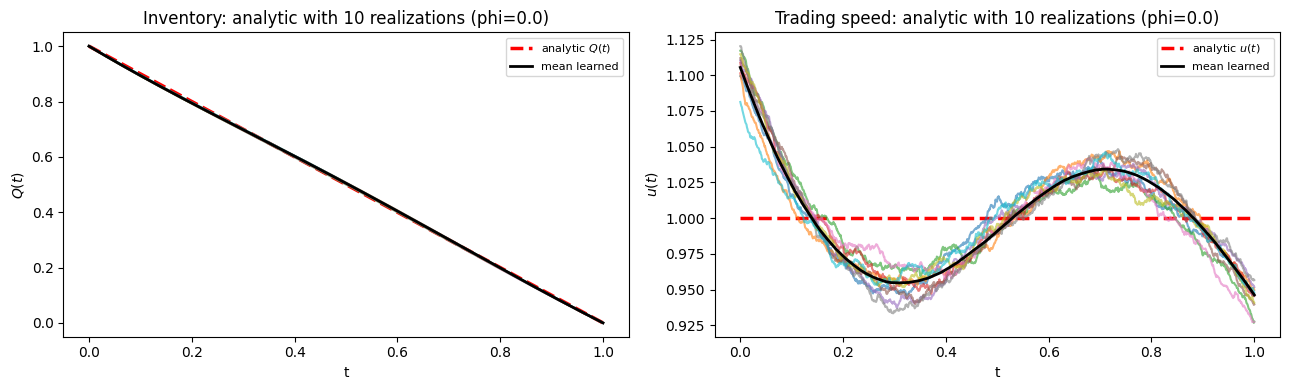

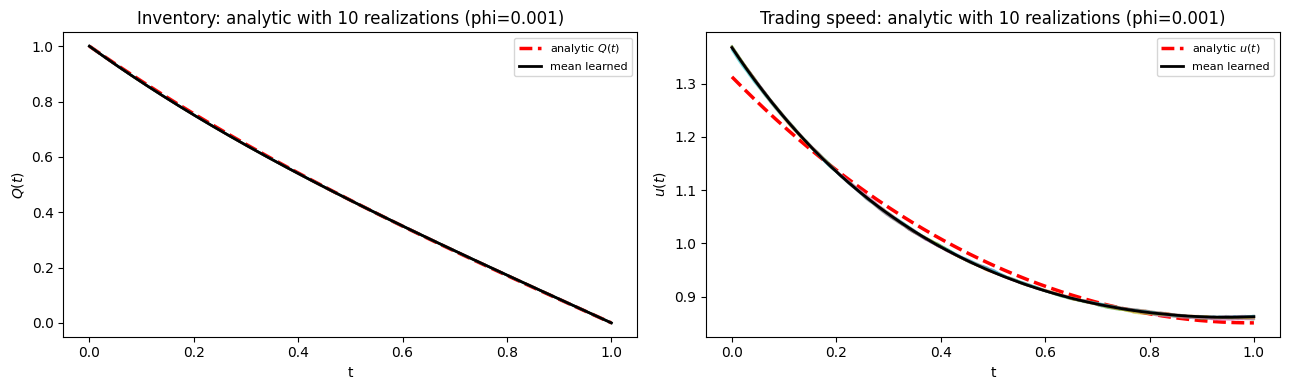

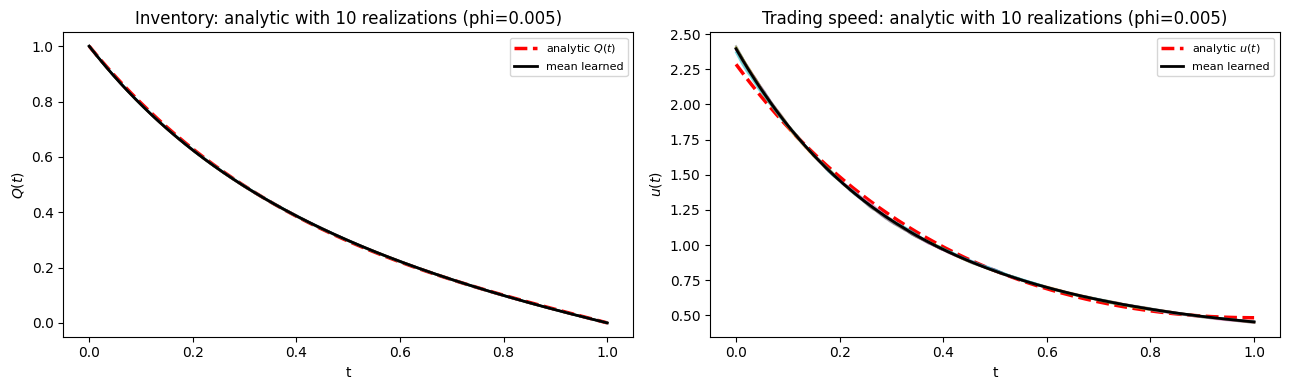

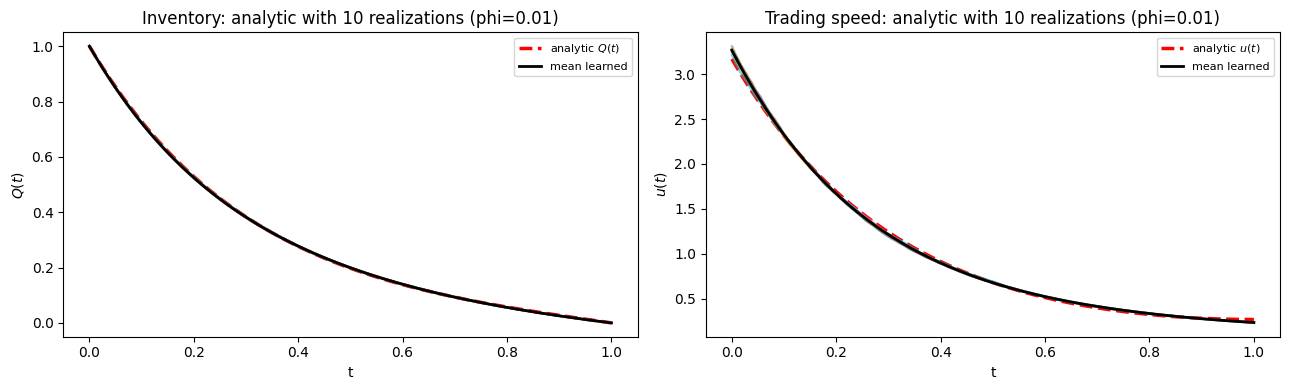

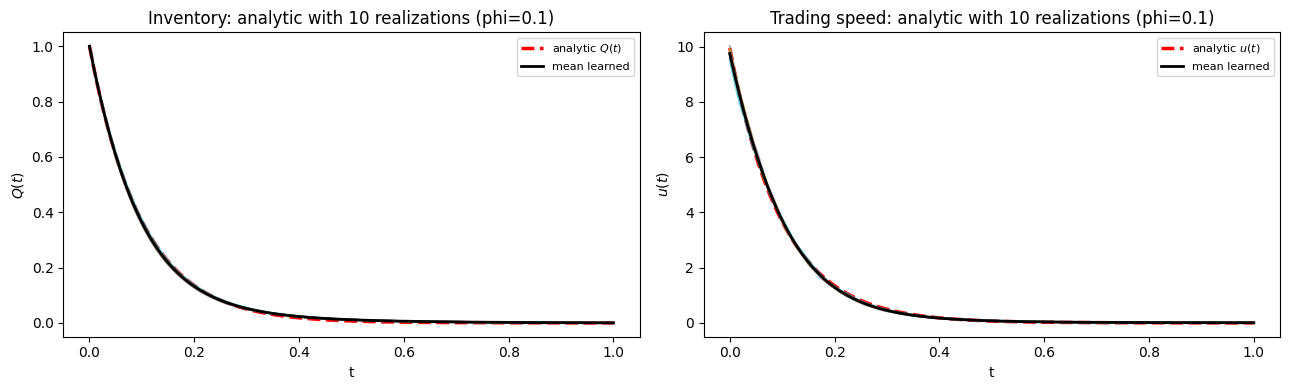

In [3]:
dtype = torch.float64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

M_train = 1000
M_test  = 1000
N = 1000
T = 1.0
dt = T/(N-1)

q0 = 1.0
lam = 1e-3
k = 1e-3
alpha = 10.0
sigma = 0.02

depth = 2

t = torch.linspace(0.0, T, N, device=device, dtype=dtype)
dt_grid = t[1:] - t[:-1]

def brownian_midprice(M, seed):
    g = torch.Generator(device="cpu")
    g.manual_seed(seed)
    Z = torch.randn(M, N-1, 1, generator=g, device=device, dtype=dtype)
    dW = (dt ** 0.5) * Z
    W1 = torch.cumsum(dW, dim=1)
    W0 = torch.zeros(M, 1, 1, device=device, dtype=dtype)
    return sigma*torch.cat([W0, W1], dim=1)

def stream_signature(X):
    S = signatory.signature(X, depth=depth, basepoint=True, stream=True)
    if S.shape[1] == N:
        return S
    if S.shape[1] == N - 1:
        S_full = torch.zeros(S.shape[0], N, S.shape[2], device=device, dtype=dtype)
        S_full[:, 1:, :] = S
        return S_full
    raise RuntimeError((S.shape, N))

class SpeedNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )
        self.sp = nn.Softplus()

    def forward(self, sig_stream, dt_grid, q0):
        out = self.net(sig_stream).squeeze(-1)
        out = self.sp(out) + 1e-12
        A = (out[:, :-1] * dt_grid.view(1, -1)).sum(dim=1, keepdim=True)
        return q0 * out / A

def train_on_expected_sig_and_test_mean(phi, epochs=1000, lr=1e-3, seed_train=0, seed_test=123):
    X_mid_train = brownian_midprice(M_train, seed=seed_train)
    t_rep_train = t.view(1, N, 1).repeat(M_train, 1, 1)
    X_path_train = torch.cat([t_rep_train, X_mid_train], dim=2)

    sig_train = stream_signature(X_path_train)
    expected_sig = sig_train.mean(dim=0).unsqueeze(0)
    Xbar_t = X_mid_train.squeeze(-1).mean(dim=0)

    model = SpeedNet(expected_sig.shape[-1]).to(device).to(dtype)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    loss_hist = []

    for _ in tqdm(range(epochs), leave=False):
        opt.zero_grad()

        theta_1 = model(expected_sig, dt_grid, q0)
        theta = theta_1.squeeze(0)

        I = torch.zeros_like(theta)
        I[1:] = torch.cumsum(theta[:-1] * dt_grid, dim=0)

        price = Xbar_t - k * I - lam * theta

        wealth = torch.zeros_like(theta)
        wealth[1:] = torch.cumsum((price[:-1] * theta[:-1]) * dt_grid, dim=0)

        inventory = q0 - I

        penalty = torch.zeros_like(theta)
        penalty[1:] = torch.cumsum((inventory[:-1] ** 2) * dt_grid, dim=0)

        obj_T = wealth[-1] - phi * penalty[-1] + inventory[-1] * (price[-1] - alpha * inventory[-1])

        loss = -obj_T
        loss_hist.append(loss.item())

        loss.backward()
        opt.step()

    X_mid_test = brownian_midprice(M_test, seed=seed_test)
    t_rep_test = t.view(1, N, 1).repeat(M_test, 1, 1)
    X_path_test = torch.cat([t_rep_test, X_mid_test], dim=2)

    sig_test = stream_signature(X_path_test)
    X_t_test = X_mid_test.squeeze(-1)

    model.eval()
    with torch.no_grad():
        theta_test = model(sig_test, dt_grid, q0)

        I = torch.zeros_like(theta_test)
        I[:, 1:] = torch.cumsum(theta_test[:, :-1] * dt_grid.view(1, -1), dim=1)

        inventory = q0 - I
        price = X_t_test - k * I - lam * theta_test

        wealth = torch.zeros_like(theta_test)
        wealth[:, 1:] = torch.cumsum((price[:, :-1] * theta_test[:, :-1]) * dt_grid.view(1, -1), dim=1)

        inventory = q0 - I

    inv_m = inventory.mean(dim=0).detach().cpu()
    th_m  = theta_test.mean(dim=0).detach().cpu()
    pr_m  = price.mean(dim=0).detach().cpu()
    we_m  = wealth.mean(dim=0).detach().cpu()

    # ----- collecting 10 realizations (for plotting only) -----
    inv_10 = inventory[:10].detach().cpu()     # (10, N)
    th_10  = theta_test[:10].detach().cpu()    # (10, N)

    return wealth, inv_m, th_m, pr_m, we_m, np.array(loss_hist), inv_10, th_10


b = 1e-3
k_ana = 1e-3
alpha_ana = 10.0

def analytic_inventory(phi, q0, k, alpha, b, t, T, eps=1e-14):
    phi_t = torch.as_tensor(phi, device=t.device, dtype=t.dtype)
    if torch.abs(phi_t) < eps:
        return q0 * (1.0 - t / T)

    gamma = torch.sqrt(phi_t / k)
    zeta = (alpha - 0.5 * b + torch.sqrt(k * phi_t)) / (alpha - 0.5 * b - torch.sqrt(k * phi_t))
    tt = T - t
    num = zeta * torch.exp(gamma * tt) - torch.exp(-gamma * tt)
    den = zeta * torch.exp(gamma * T)  - torch.exp(-gamma * T)
    return q0 * num / den

def speed_from_Q(Q, dt_grid):
    u = torch.zeros_like(Q)
    u[:-1] = (Q[:-1] - Q[1:]) / dt_grid
    u[-1] = u[-2]
    return u


phis = [0.0, 0.001, 0.005, 0.01, 0.1]
t_cpu = t.detach().cpu().numpy()

wealth_curves, inv_curves, th_curves, pr_curves, we_curves, loss_curves = {}, {}, {}, {}, {}, {}
inv10_curves, th10_curves = {}, {}

for phi in phis:
    wealth, inv_m, th_m, pr_m, we_m, loss_hist, inv_10, th_10 = train_on_expected_sig_and_test_mean(
        phi, epochs=500, lr=1e-3
    )
    inv_curves[phi] = inv_m
    th_curves[phi]  = th_m
    pr_curves[phi]  = pr_m
    we_curves[phi]  = we_m
    loss_curves[phi] = loss_hist
    wealth_curves[phi] = wealth

    inv10_curves[phi] = inv_10.numpy()   # (10, N)
    th10_curves[phi]  = th_10.numpy()    # (10, N)

##Plotting

for phi in phis:
    Q_an_t = analytic_inventory(phi, q0, k_ana, alpha_ana, b, t, T)
    u_an_t = speed_from_Q(Q_an_t, dt_grid)

    Q_an = Q_an_t.detach().cpu().numpy()
    u_an = u_an_t.detach().cpu().numpy()

    Q_10 = inv10_curves[phi]   # (10, N)
    u_10 = th10_curves[phi]    # (10, N)

    fig, axs = plt.subplots(1, 2, figsize=(13, 4))


    axs[0].plot(t_cpu, Q_an, "r--", linewidth=2.5, label="analytic $Q(t)$")
    for i in range(Q_10.shape[0]):
        axs[0].plot(t_cpu, Q_10[i], alpha=0.6)
    axs[0].plot(t_cpu, inv_curves[phi].numpy(), "k", linewidth=2.0, label="mean learned")
    axs[0].set_title(f"Inventory: analytic with 10 realizations (phi={phi})")
    axs[0].set_xlabel("t")
    axs[0].set_ylabel("$Q(t)$")
    axs[0].legend(fontsize=8)

    axs[1].plot(t_cpu, u_an, "r--", linewidth=2.5, label="analytic $u(t)$")
    for i in range(u_10.shape[0]):
        axs[1].plot(t_cpu, u_10[i], alpha=0.6)
    axs[1].plot(t_cpu, th_curves[phi].numpy(), "k", linewidth=2.0, label="mean learned")
    axs[1].set_title(f"Trading speed: analytic with 10 realizations (phi={phi})")
    axs[1].set_xlabel("t")
    axs[1].set_ylabel("$u(t)$")
    axs[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

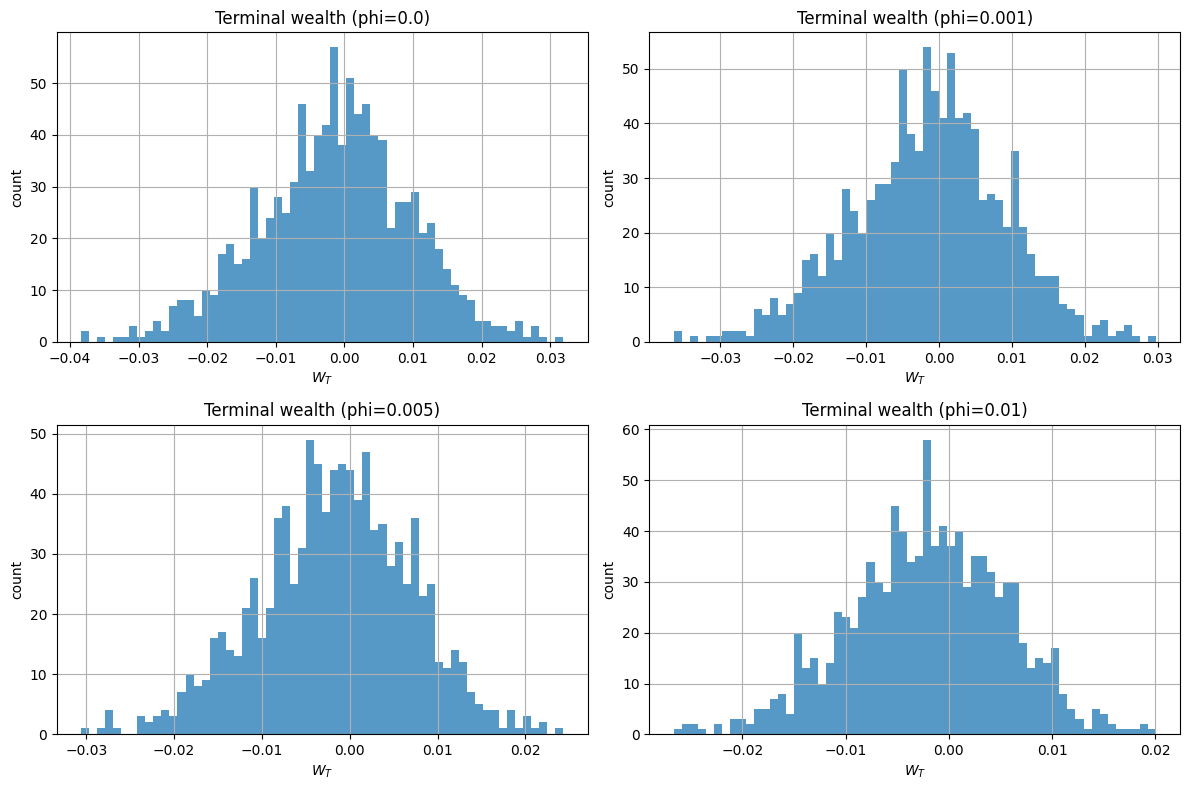

In [4]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.ravel()

for ax, phi in zip(axs, phis):
    W_T = wealth_curves[phi][:, -1].detach().cpu().numpy()  # (M_test,)
    ax.hist(W_T, bins=60, alpha=0.75)
    ax.set_title(f"Terminal wealth (phi={phi})")
    ax.set_xlabel(r"$W_T$")
    ax.set_ylabel("count")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [5]:
def davies_harte(N, T, H):
    gamma = lambda k,H: 0.5*(np.abs(k-1)**(2*H) - 2*np.abs(k)**(2*H) + np.abs(k+1)**(2*H))
    g = [gamma(k,H) for k in range(0,N)];    r = g + [0] + g[::-1][0:N-1]

    # Step 1 (eigenvalues)
    j = np.arange(0,2*N);   k = 2*N-1
    lk = np.fft.fft(r*np.exp(2*np.pi*complex(0,1)*k*j*(1/(2*N))))[::-1]

    # Step 2 (get random variables)
    Vj = np.zeros((2*N,2), dtype=complex);
    Vj[0,0] = np.random.standard_normal();  Vj[N,0] = np.random.standard_normal()

    for i in range(1,N):
        Vj1 = np.random.standard_normal();    Vj2 = np.random.standard_normal()
        Vj[i][0] = Vj1; Vj[i][1] = Vj2; Vj[2*N-i][0] = Vj1;    Vj[2*N-i][1] = Vj2

    # Step 3 (compute Z)
    wk = np.zeros(2*N, dtype=complex)
    wk[0] = np.sqrt((lk[0]/(2*N)))*Vj[0][0];
    wk[1:N] = np.sqrt(lk[1:N]/(4*N))*((Vj[1:N].T[0]) + (complex(0,1)*Vj[1:N].T[1]))
    wk[N] = np.sqrt((lk[0]/(2*N)))*Vj[N][0]
    wk[N+1:2*N] = np.sqrt(lk[N+1:2*N]/(4*N))*(np.flip(Vj[1:N].T[0]) - (complex(0,1)*np.flip(Vj[1:N].T[1])))

    Z = np.fft.fft(wk);     fGn = Z[0:N]
    fBm = np.cumsum(fGn)*(N**(-H))
    fBm = (T**H)*(fBm)
    path = np.array([0] + list(fBm))
    return path


#new parameters
H = 0.25
S0 = 1
V0 = 0.8
a = 0.02
#b = 3
b = 0.02
c = 3.0
d = 0.0001


np.random.seed(3)
dW = np.random.randn(N)
W = np.zeros(N)
for i in range(1,N):
    W[i] = W[i-1] + dW[i]*np.sqrt(dt)

B = davies_harte(N, T, H)
B = B[:-1].real.astype(float)


def A(x):
  return np.sqrt(a*(x - a)**2 + a)
def C(x):
  return -0.5*((a**2*(x - a)*(x**b))/(np.sqrt(a*(x - a)**2 + a)) + a*(x - a)**2 + a)

S = np.zeros(N)
V = np.zeros(N)
S[0], V[0] = S0, V0
for k in range(1,N):
  S[k] = S[k-1] + a*V[k-1]*S[k-1]*(W[k] - W[k-1])
  V[k] = V[k-1] + b*V[k-1]*(B[k] - B[k-1])


  #S[k] = S[k-1] + c*A(V[k-1])*S[k-1]*(W[k] - W[k-1]) + d*C(V[k-1])*S[k-1]*dt
  #V[k] = V[k-1] + c*V0**b*(B[k] - B[k-1]) + c*a*V[k-1]**b*(W[k] - W[k-1]) + d*a*(1 + V[k-1])*dt


#S_exact = S0*np.exp(a*W - (a**2/2) * t)
#V_exact = V0*np.exp(b*B - (b**2/2) * t**(2*H))

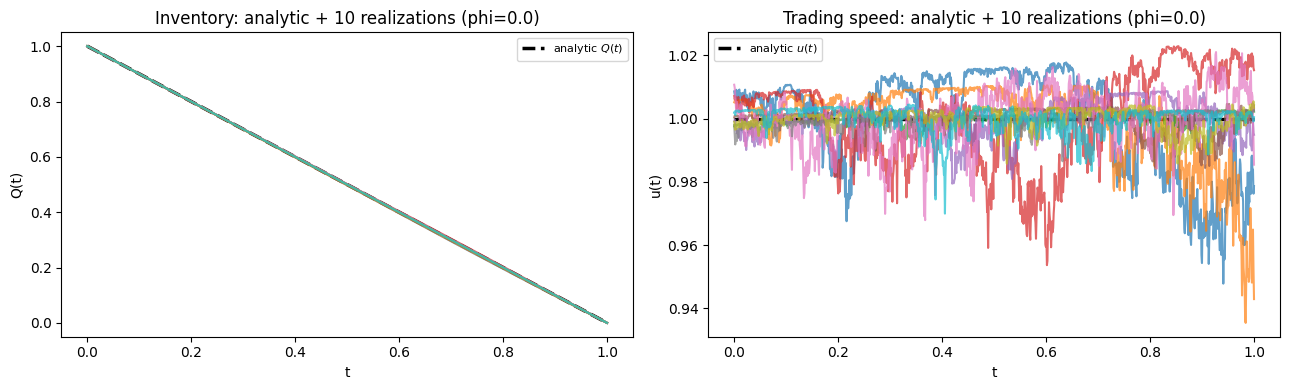

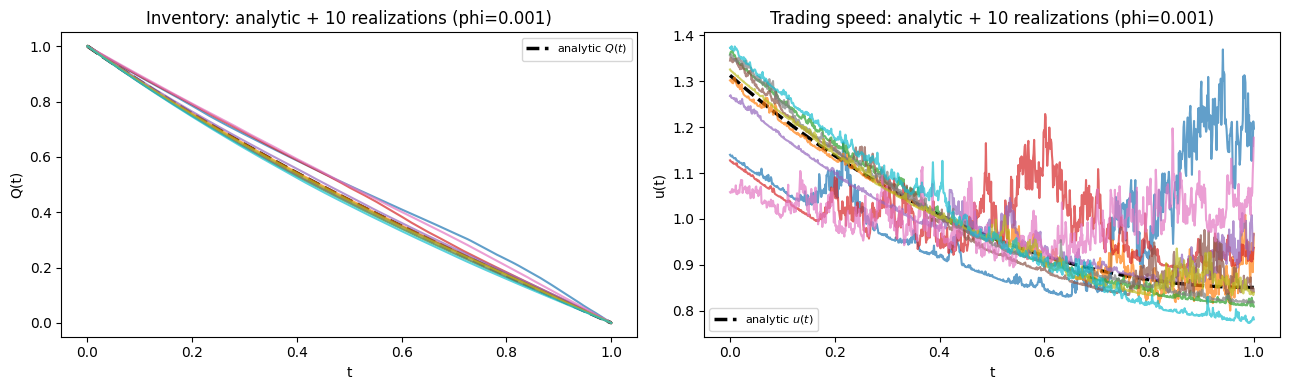

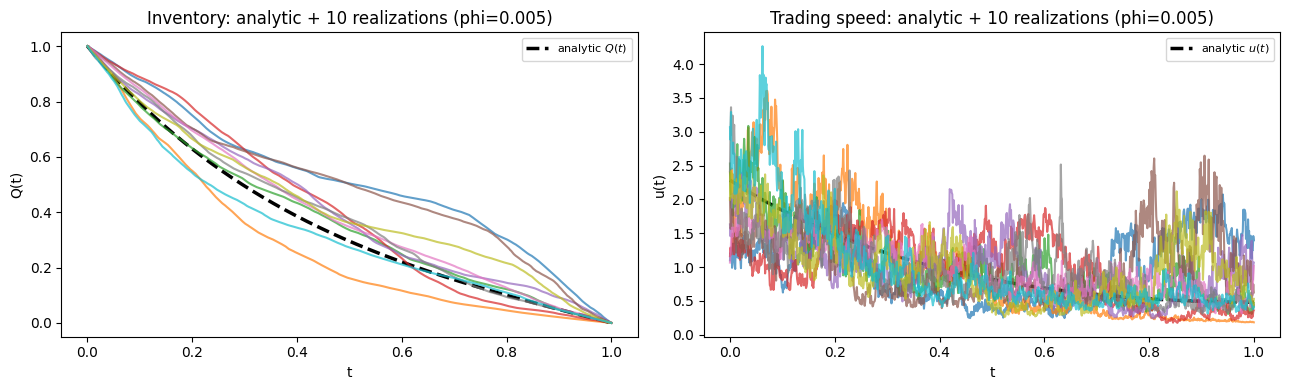

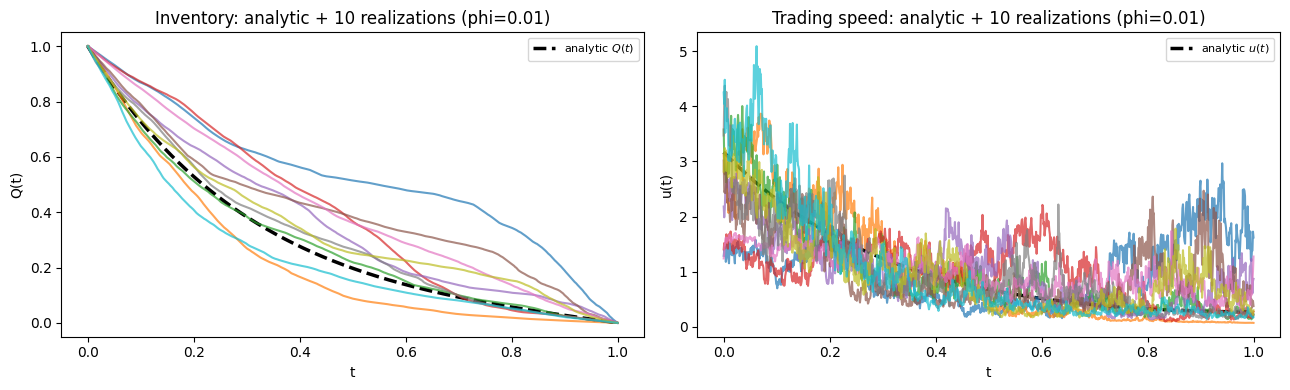

In [6]:
# ============================================================
# SAME CODE (training + simulation) with ONLY these changes:
#   1) add analytic_inventory + speed_from_Q (for plotting)
#   2) return 10 realizations (inventory + speed) from test set
#   3) replace plotting: for each phi plot (analytic + 10 realizations)
#       for inventory and trading speed ONLY
# ============================================================

import torch
import torch.nn as nn
import signatory
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

dtype = torch.float64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

M_train = 1000
M_test  = 1000
N = 1000
T = 1.0
dt = T/(N-1)

q0 = 1.0
lam = 1e-3
k = 1e-4
alpha = 10.0
sigma = 0.02
H = 0.25

depth = 2

t = torch.linspace(0.0, T, N, device=device, dtype=dtype)
dt_grid = t[1:] - t[:-1]

# ----------------------------
# Analytic inventory (ONLY for plotting)
# ----------------------------
b_ana = 0.001
k_ana = 1e-3
alpha_ana = 100.0

def analytic_inventory(phi, q0, k, alpha, b, t, T, eps=1e-14):
    phi_t = torch.as_tensor(phi, device=t.device, dtype=t.dtype)
    if torch.abs(phi_t) < eps:
        return q0 * (1.0 - t / T)

    gamma = torch.sqrt(phi_t / k)
    zeta = (alpha - 0.5 * b + torch.sqrt(k * phi_t)) / (alpha - 0.5 * b - torch.sqrt(k * phi_t))
    tt = T - t
    num = zeta * torch.exp(gamma * tt) - torch.exp(-gamma * tt)
    den = zeta * torch.exp(gamma * T)  - torch.exp(-gamma * T)
    return q0 * num / den

def speed_from_Q(Q, dt_grid):
    u = torch.zeros_like(Q)
    u[:-1] = (Q[:-1] - Q[1:]) / dt_grid
    u[-1] = u[-2]
    return u

# ----------------------------
# Your existing functions
# ----------------------------
def brownian_midprice(M, seed):
    g = torch.Generator(device="cpu")
    g.manual_seed(seed)
    Z = torch.randn(M, N-1, 1, generator=g, device=device, dtype=dtype)
    dW = (dt ** 0.5) * Z
    W1 = torch.cumsum(dW, dim=1)
    W0 = torch.zeros(M, 1, 1, device=device, dtype=dtype)
    return sigma * torch.cat([W0, W1], dim=1)

def fbm_davies_harte(M, N, T, H, seed, device="cpu", dtype=torch.float64):
    paths = np.empty((M, N), dtype=np.float64)
    for m in range(M):
        np.random.seed(seed + m)
        B = davies_harte(N, T, H)
        B = B.real.astype(np.float64)
        if B.shape[0] == N + 1:
            B = B[:-1]
        elif B.shape[0] == N:
            pass
        elif B.shape[0] == N - 1:
            B = np.concatenate([np.array([0.0], dtype=np.float64), B])
        else:
            raise ValueError(f"Unexpected length from davies_harte: {B.shape[0]} (expected N-1, N, or N+1)")
        paths[m, :] = B
    return torch.tensor(paths, device=device, dtype=dtype).unsqueeze(-1)

def price_process(a, b, BM, FBM, S0, V0):
    if BM.shape != FBM.shape:
        raise ValueError(f"BM and FBM must have the same shape, got {BM.shape} and {FBM.shape}")
    if BM.dim() != 3 or BM.size(-1) != 1:
        raise ValueError(f"BM must have shape (M, N, 1), got {BM.shape}")

    M, N, _ = BM.shape
    device = BM.device
    dtype = BM.dtype

    a = torch.as_tensor(a, device=device, dtype=dtype)
    b = torch.as_tensor(b, device=device, dtype=dtype)
    S0 = torch.as_tensor(S0, device=device, dtype=dtype).view(1, 1, 1)
    V0 = torch.as_tensor(V0, device=device, dtype=dtype).view(1, 1, 1)

    dW = BM[:, 1:, :] - BM[:, :-1, :]
    dB = FBM[:, 1:, :] - FBM[:, :-1, :]

    S = torch.empty((M, N, 1), device=device, dtype=dtype)
    V = torch.empty((M, N, 1), device=device, dtype=dtype)

    S[:, 0:1, :] = S0
    V[:, 0:1, :] = V0

    for k_ in range(1, N):
        Skm1 = S[:, k_-1:k_, :]
        Vkm1 = V[:, k_-1:k_, :]
        S[:, k_:k_+1, :] = Skm1 + a * Vkm1 * Skm1 * dW[:, k_-1:k_, :]
        V[:, k_:k_+1, :] = Vkm1 + b * Vkm1 * dB[:, k_-1:k_, :]

    return S, V

def stream_signature(X):
    S = signatory.signature(X, depth=depth, basepoint=True, stream=True)
    if S.shape[1] == N:
        return S
    if S.shape[1] == N - 1:
        S_full = torch.zeros(S.shape[0], N, S.shape[2], device=device, dtype=dtype)
        S_full[:, 1:, :] = S
        return S_full
    raise RuntimeError((S.shape, N))

class SpeedNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )
        self.sp = nn.Softplus()        #always positive

    def forward(self, sig_stream, dt_grid, q0):
        out = self.net(sig_stream).squeeze(-1)
        out = self.sp(out) + 1e-12
        A = (out[:, :-1] * dt_grid.view(1, -1)).sum(dim=1, keepdim=True)
        return q0 * out / A

# ----------------------------
# Train + return 10 test realizations
# ----------------------------
phis = [0.0, 0.001, 0.005, 0.01]

def train_on_expected_sig_and_test_mean(phi, epochs=1000, lr=1e-3, seed_train=0, seed_test=123):
    X_mid_train = brownian_midprice(M_train, seed=seed_train)
    fBm_train = fbm_davies_harte(M_train, N, T, H, seed=seed_train, device="cpu", dtype=torch.float64)
    t_rep_train = t.view(1, N, 1).repeat(M_train, 1, 1)
    X_path_train = torch.cat([t_rep_train, X_mid_train, fBm_train], dim=2)

    sig_train = stream_signature(X_path_train)
    expected_sig = sig_train.mean(dim=0).unsqueeze(0)

    S, V = price_process(a, b, X_mid_train, fBm_train, S0, V0)
    Xbar_t = S.squeeze(-1).mean(dim=0)

    model = SpeedNet(expected_sig.shape[-1]).to(device).to(dtype)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    loss_hist = []
    for _ in tqdm(range(epochs), leave=False):
        opt.zero_grad()

        theta_1 = model(expected_sig, dt_grid, q0)
        theta = theta_1.squeeze(0)

        I = torch.zeros_like(theta)
        I[1:] = torch.cumsum(theta[:-1] * dt_grid, dim=0)

        price = Xbar_t - k * I - lam * theta

        wealth = torch.zeros_like(theta)
        wealth[1:] = torch.cumsum((price[:-1] * theta[:-1]) * dt_grid, dim=0)

        inventory = q0 - I

        penalty = torch.zeros_like(theta)
        penalty[1:] = torch.cumsum((inventory[:-1] ** 2) * dt_grid, dim=0)

        obj_T = wealth[-1] - phi * penalty[-1] + inventory[-1] * (price[-1] - alpha * inventory[-1])
        loss = -obj_T
        loss_hist.append(loss.item())

        loss.backward()
        opt.step()

    # ----- test -----
    X_mid_test = brownian_midprice(M_test, seed=seed_test)
    fBm_test = fbm_davies_harte(M_test, N, T, H, seed=seed_test, device="cpu", dtype=torch.float64)
    t_rep_test = t.view(1, N, 1).repeat(M_test, 1, 1)
    X_path_test = torch.cat([t_rep_test, X_mid_test, fBm_test], dim=2)

    sig_test = stream_signature(X_path_test)
    S_test, V_test = price_process(a, b, X_mid_test, fBm_test, S0, V0)
    X_t_test = S_test.squeeze(-1).mean(dim=0)

    model.eval()
    with torch.no_grad():
        theta_test = model(sig_test, dt_grid, q0)  # (M_test, N)

        I = torch.zeros_like(theta_test)
        I[:, 1:] = torch.cumsum(theta_test[:, :-1] * dt_grid.view(1, -1), dim=1)

        inventory = q0 - I
        price = X_t_test - lam * theta_test

        wealth = torch.zeros_like(theta_test)
        wealth[:, 1:] = torch.cumsum((price[:, :-1] * theta_test[:, :-1]) * dt_grid.view(1, -1), dim=1)

    # 10 realizations
    inv_10 = inventory[:10].detach().cpu().numpy()     # (10, N)
    th_10  = theta_test[:10].detach().cpu().numpy()    # (10, N)
    wealth_T = wealth[:, -1].detach().cpu().numpy()
    return inv_10, th_10, np.array(loss_hist), wealth_T

# ----------------------------
# Run + plot (inventory/speed only): analytic + 10 realizations
# ----------------------------
t_cpu = t.detach().cpu().numpy()

results_10 = {}
for phi in phis:
    inv_10, th_10, loss_hist, wealth_T = train_on_expected_sig_and_test_mean(phi, epochs=1000, lr=1e-3)
    results_10[phi] = {"inv_10": inv_10, "th_10": th_10, "loss": loss_hist, "wealth_T": wealth_T}

for phi in phis:
    # analytic curves (plotting only)
    Q_an = analytic_inventory(phi, q0, k_ana, alpha_ana, b_ana, t, T).detach().cpu().numpy()
    u_an = speed_from_Q(torch.tensor(Q_an, dtype=dtype), dt_grid.cpu()).numpy()

    inv_10 = results_10[phi]["inv_10"]  # (10, N)
    th_10  = results_10[phi]["th_10"]   # (10, N)

    fig, axs = plt.subplots(1, 2, figsize=(13, 4))

    # Inventory: analytic + 10 realizations
    axs[0].plot(t_cpu, Q_an, "k--", linewidth=2.5, label="analytic $Q(t)$")
    for i in range(10):
        axs[0].plot(t_cpu, inv_10[i], alpha=0.7)
    axs[0].set_title(f"Inventory: analytic + 10 realizations (phi={phi})")
    axs[0].set_xlabel("t")
    axs[0].set_ylabel("Q(t)")
    axs[0].legend(fontsize=8)

    # Speed: analytic + 10 realizations
    axs[1].plot(t_cpu, u_an, "k--", linewidth=2.5, label="analytic $u(t)$")
    for i in range(10):
        axs[1].plot(t_cpu, th_10[i], alpha=0.7)
    axs[1].set_title(f"Trading speed: analytic + 10 realizations (phi={phi})")
    axs[1].set_xlabel("t")
    axs[1].set_ylabel("u(t)")
    axs[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

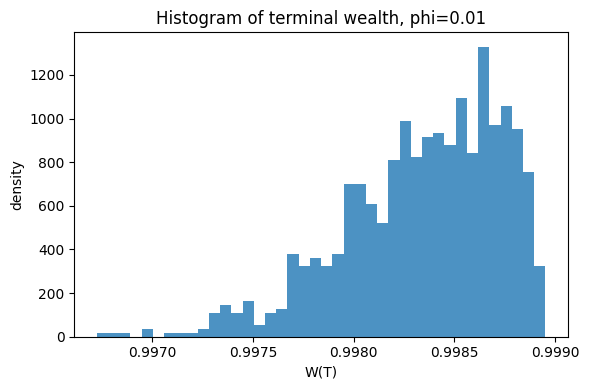

In [7]:
phi0 = 0.01
w = results_10[phi0]["wealth_T"]

plt.figure(figsize=(6,4))
plt.hist(w, bins=40, density=True, alpha=0.8)
plt.title(f"Histogram of terminal wealth, phi={phi0}")
plt.xlabel("W(T)")
plt.ylabel("density")
plt.tight_layout()
plt.show()

In [8]:
class Path_extension(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(Path_extension, self).__init__()
        hidden_dims = [512, 256, 128, 64, 32, 16]
        self.fc1 = nn.Linear(input_dim, hidden_dims[0])
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.fc3 = nn.Linear(hidden_dims[1], hidden_dims[2])
        self.fc4 = nn.Linear(hidden_dims[2], hidden_dims[3])
        self.fc5 = nn.Linear(hidden_dims[3], hidden_dims[4])
        self.fc6 = nn.Linear(hidden_dims[4], hidden_dims[5])
        self.out = nn.Linear(hidden_dims[5], output_dim)
        self.act = nn.Tanh()
    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.act(self.fc3(x))
        x = self.act(self.fc4(x))
        x = self.act(self.fc5(x))
        x = self.act(self.fc6(x))
        return self.out(x)


def shuffle_loss_function(X):
    dX = X[:, 1:, :] - X[:, :-1, :]
    X_left = X[:, :-1, :]
    I = torch.einsum("mta,mtb->mab", X_left, dX)
    deltas = X[:, -1, :] - X[:, 0, :]
    outer = deltas[:, :, None] * deltas[:, None, :]
    R = outer - (I + I.transpose(-1, -2))
    loss_per_path = torch.triu(R.pow(2), diagonal=0).sum(dim=(-2, -1))
    return loss_per_path.mean()


def shuffle_loss_residual(X_bar):
    dX = X_bar[1:, :] - X_bar[:-1, :]
    X_left = X_bar[:-1, :]
    I = torch.einsum('ka,kb->ab', X_left, dX)
    deltas = X_bar[-1, :] - X_bar[0, :]
    R = deltas[:, None] * deltas[None, :] - (I + I.T)
    return R


#paramters
epochs        = 100
lr            = 1e-3
sig_depth1    = 2
sig_depth2    = 2
lambda_1   = 10.0
lambda_2  = 1.0
M = 100
N = 1000
T = 1.0
dt = T/N
t = torch.linspace(0.0, T, N, device=device, dtype=dtype)
seed_train = 5
seed_test = 2

#training data
X_mid_train = brownian_midprice(M, seed=seed_train)
fBm_train = fbm_davies_harte(M, N, T, H, seed=seed_train, device="cpu", dtype=torch.float64)
t_rep_train = t.view(1, N, 1).repeat(M, 1, 1)
X_path_train = torch.cat([t_rep_train, X_mid_train, fBm_train], dim=2)
S, V = price_process(a, b, X_mid_train, fBm_train, S0, V0)

#set-up
error_array = []
shuffle_loss_array = []
device = X_path_train.device
M1, N1, d1 = X_path_train.shape                  #shape of the input data
model   = Path_extension(input_dim=d1, output_dim=4).to(device).to(dtype)
d2 = model(X_path_train).shape[2]            #output dimension from the extension
d3 = d1 + d2
d4 = signatory.signature_channels(d3, depth=sig_depth1) #number of components of the signature
linear1 = nn.Linear(d4, 1, bias=False).to(device).to(dtype) #first linear layer

#Training
optimizer = torch.optim.Adam(list(model.parameters()),lr=lr)
mse = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

for epoch in tqdm(range(1, epochs + 1)):
  #model.train(); linear1.train(); linear2.train()
  optimizer.zero_grad()
  out1 = model(X_path_train)
  shuffle_loss = shuffle_loss_function(out1)
  shuffle_loss_array.append(shuffle_loss.item())
  stack1 = torch.cat([X_path_train, out1], dim=2)
  sig1 = signatory.signature(stack1, depth=sig_depth1, basepoint=True, stream=True)
  pred1 = linear1(sig1)

  error1 = mse(pred1, V)
  error_array.append(error1.item())
  Final_error = lambda_1*error1 + lambda_2*shuffle_loss
  Final_error.backward()
  optimizer.step()
  scheduler.step()

100%|██████████| 100/100 [10:25<00:00,  6.25s/it]


MSE (with extension):   mean=3.270249e-10, std=9.958907e-11
MSE (without extension): mean=1.093745e-09, std=5.001758e-10


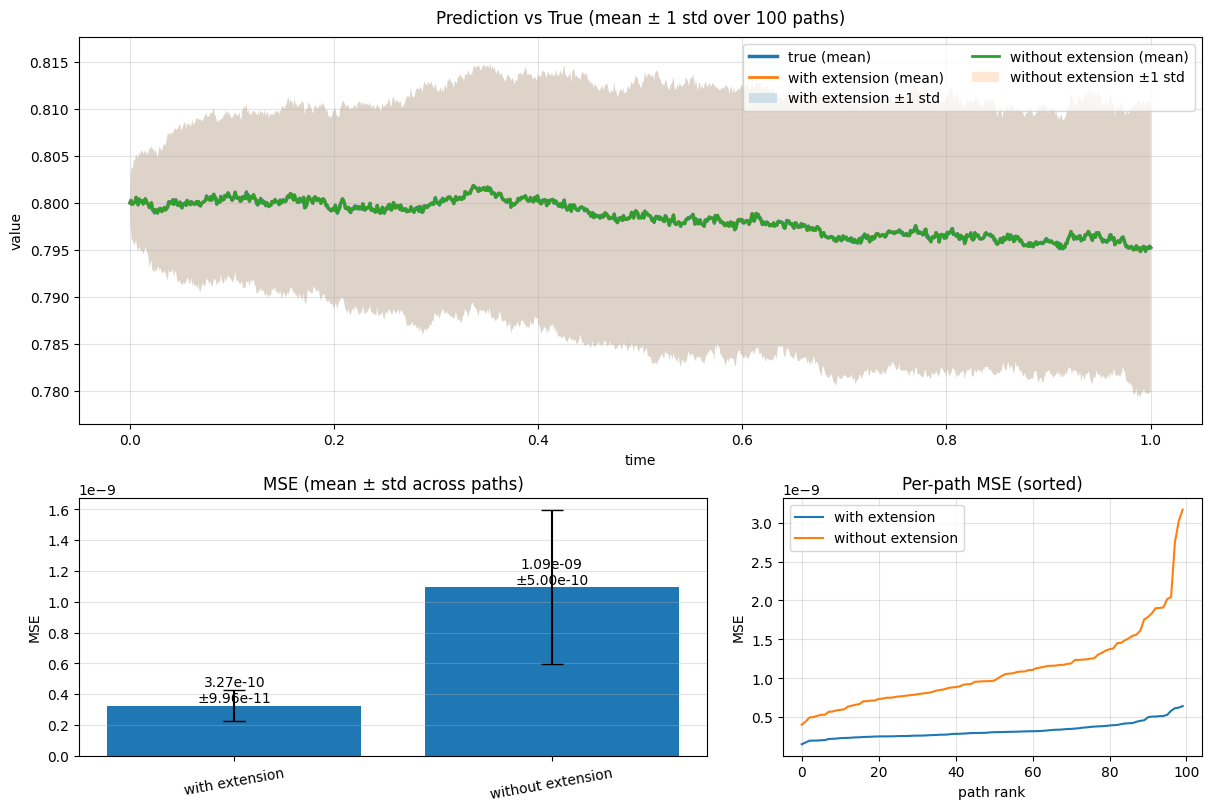

In [9]:
M_test = 100
a = 0.02
#b = 3
b = 0.02

seed_test = 123  # base seed
X_mid_test = brownian_midprice(M_test, seed=seed_test)
fBm_test   = fbm_davies_harte(M_test, N, T, H, seed=seed_test, device=X_mid_test.device, dtype=X_mid_test.dtype)

t_rep_test = t.view(1, N, 1).repeat(M_test, 1, 1)
X_path_test = torch.cat([t_rep_test, X_mid_test, fBm_test], dim=2)

S_test, V_test = price_process(a, b, X_mid_test, fBm_test, S0, V0)  # V_test: (M,N,1) or (M,N)

# Make target shape (M,N)
if V_test.dim() == 3:
    V_true = V_test.squeeze(-1)
else:
    V_true = V_test

# ----------------------------
# Compute signatures (batch)
# ----------------------------
model.eval()
with torch.no_grad():
    out1_ = model(X_path_test)  # should be (M,N,1) so that cat works
stack1_ = torch.cat([X_path_test, out1_], dim=2)

sig_with = signatory.signature(stack1_, depth=sig_depth1, basepoint=True, stream=True)   # (M,N,D1)
sig_wo   = signatory.signature(X_path_test, depth=sig_depth1, basepoint=True, stream=True)  # (M,N,D0)

# Move to CPU numpy for sklearn
sig_with_np = sig_with.detach().cpu().numpy()
sig_wo_np   = sig_wo.detach().cpu().numpy()
V_true_np   = V_true.detach().cpu().numpy()

# ----------------------------
# Fit per-path linear regression and predict
# ----------------------------
y_hat_with = np.empty((M_test, N), dtype=float)
y_hat_wo   = np.empty((M_test, N), dtype=float)

mse_with = np.empty(M_test, dtype=float)
mse_wo   = np.empty(M_test, dtype=float)

for m in range(M_test):
    Xw = sig_with_np[m]           # (N, D1)
    Xo = sig_wo_np[m]             # (N, D0)
    y  = V_true_np[m]             # (N,)

    # with extension
    clf = linear_model.LinearRegression()
    clf.fit(Xw, y)
    y_pred_w = clf.predict(Xw)

    # without extension
    clf1 = linear_model.LinearRegression()
    clf1.fit(Xo, y)
    y_pred_o = clf1.predict(Xo)

    y_hat_with[m] = y_pred_w
    y_hat_wo[m]   = y_pred_o

    mse_with[m] = mean_squared_error(y, y_pred_w)
    mse_wo[m]   = mean_squared_error(y, y_pred_o)

print(f"MSE (with extension):   mean={mse_with.mean():.6e}, std={mse_with.std():.6e}")
print(f"MSE (without extension): mean={mse_wo.mean():.6e}, std={mse_wo.std():.6e}")

# ----------------------------
# Plot: mean ± std band + MSE bar chart
# ----------------------------
t_cpu = t.detach().cpu().numpy()

true_mean = V_true_np.mean(axis=0)
w_mean    = y_hat_with.mean(axis=0)
w_std     = y_hat_with.std(axis=0)

o_mean    = y_hat_wo.mean(axis=0)
o_std     = y_hat_wo.std(axis=0)


fig = plt.figure(figsize=(12, 8), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[3, 2], width_ratios=[3, 2])

ax0 = fig.add_subplot(gs[0, :])   # top spans both columns
ax1 = fig.add_subplot(gs[1, 0])   # bottom-left: MSE bars
ax2 = fig.add_subplot(gs[1, 1])   # bottom-right: MSE scan / distribution

# ---------------- Top: mean curves + bands ----------------
ax0.plot(t_cpu, true_mean, lw=2.5, label="true (mean)")
ax0.plot(t_cpu, w_mean,   lw=2.0, label="with extension (mean)")
ax0.fill_between(t_cpu, w_mean - w_std, w_mean + w_std, alpha=0.18, label="with extension ±1 std")

ax0.plot(t_cpu, o_mean,   lw=2.0, label="without extension (mean)")
ax0.fill_between(t_cpu, o_mean - o_std, o_mean + o_std, alpha=0.18, label="without extension ±1 std")

ax0.set_title("Prediction vs True (mean ± 1 std over 100 paths)", pad=10)
ax0.set_xlabel("time")
ax0.set_ylabel("value")
ax0.grid(True, alpha=0.35)
ax0.legend(ncol=2, frameon=True, loc="upper right")

# Optional: zoom to the visible region with a small margin
y_min = min((true_mean - 0).min(), (w_mean - w_std).min(), (o_mean - o_std).min())
y_max = max((true_mean + 0).max(), (w_mean + w_std).max(), (o_mean + o_std).max())
pad = 0.08 * (y_max - y_min + 1e-12)
ax0.set_ylim(y_min - pad, y_max + pad)

# ---------------- Bottom-left: bar chart with error bars ----------------
means = np.array([mse_with.mean(), mse_wo.mean()])
stds  = np.array([mse_with.std(ddof=0), mse_wo.std(ddof=0)])
labels = ["with extension", "without extension"]
x = np.arange(len(labels))

bars = ax1.bar(x, means, yerr=stds, capsize=8)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=10)
ax1.set_title("MSE (mean ± std across paths)")
ax1.set_ylabel("MSE")
ax1.grid(True, axis="y", alpha=0.35)

# Put the numbers on top of the bars
for i, b in enumerate(bars):
    ax1.text(b.get_x() + b.get_width()/2, b.get_height(),
             f"{means[i]:.2e}\n±{stds[i]:.2e}",
             ha="center", va="bottom")

# ---------------- Bottom-right: distribution / per-path MSE curve ----------------
# This gives a clearer picture than just error bars.
ax2.plot(np.sort(mse_with), label="with extension")
ax2.plot(np.sort(mse_wo),   label="without extension")
ax2.set_title("Per-path MSE (sorted)")
ax2.set_xlabel("path rank")
ax2.set_ylabel("MSE")
ax2.grid(True, alpha=0.35)
ax2.legend(frameon=True)

plt.show()

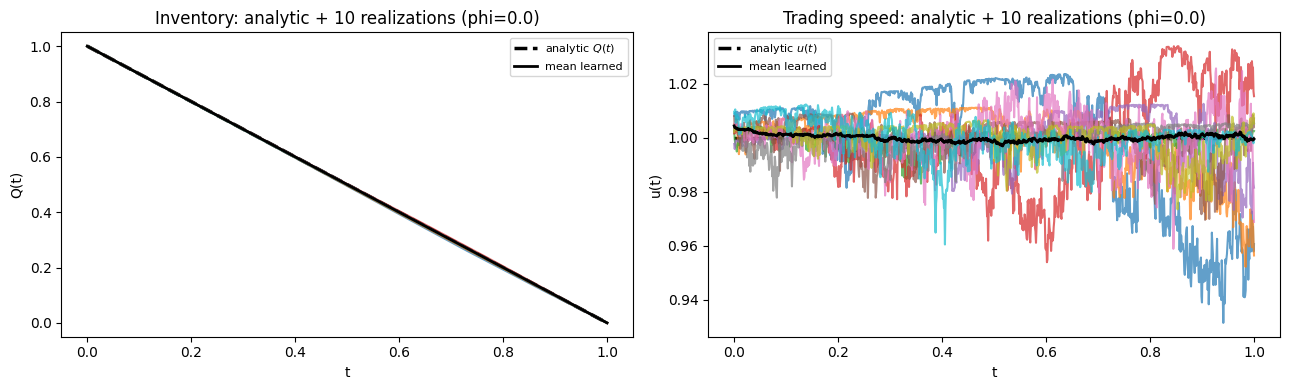

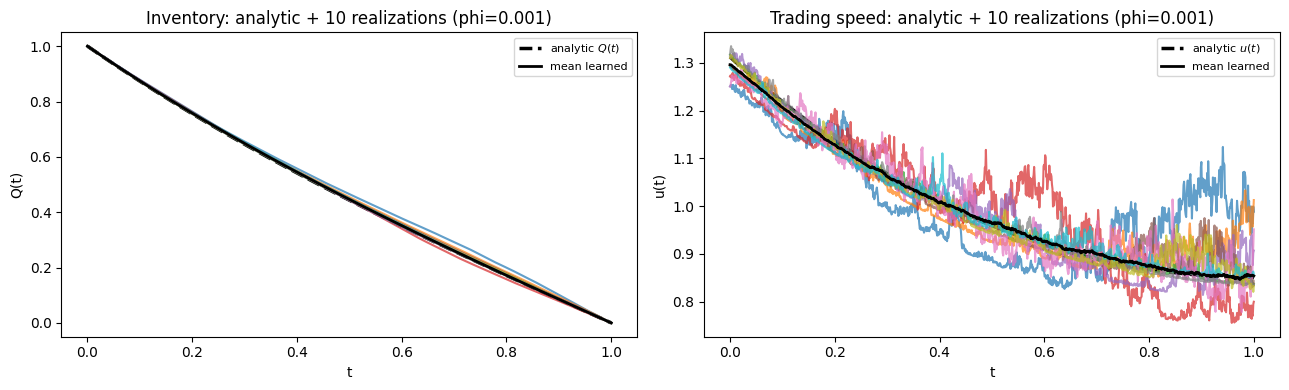

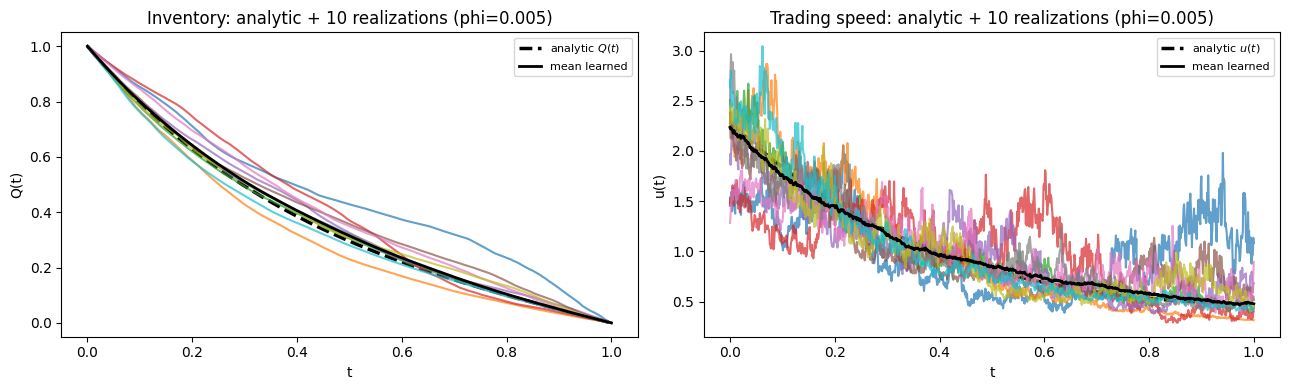

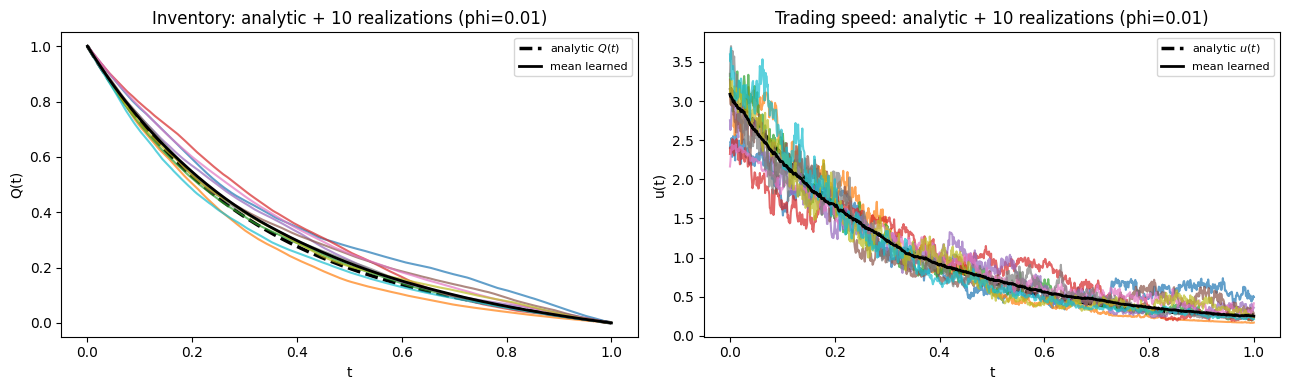

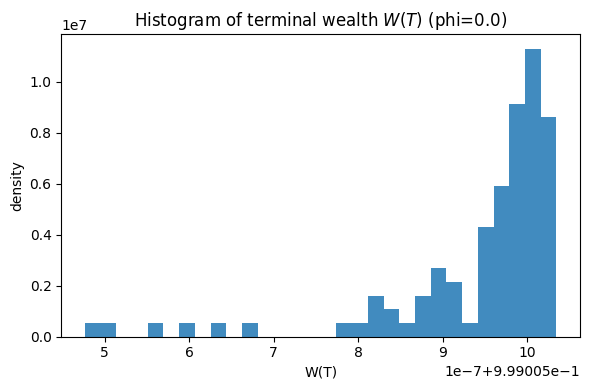

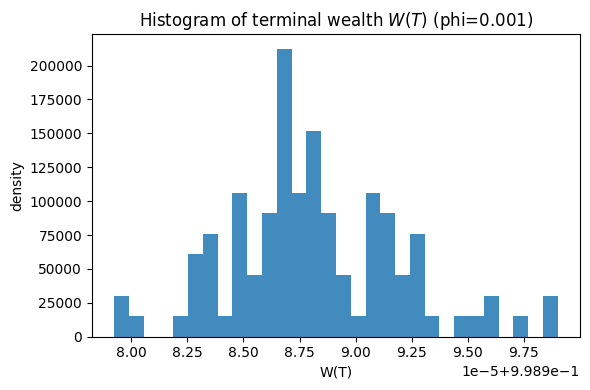

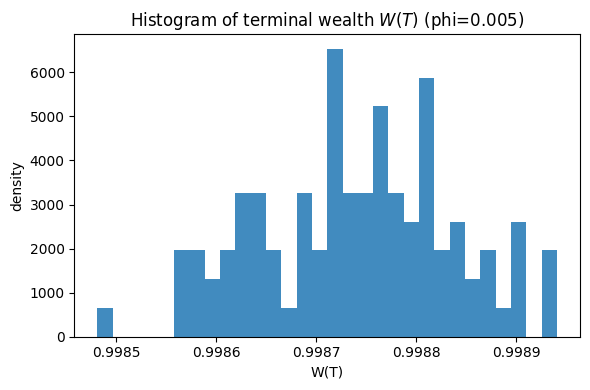

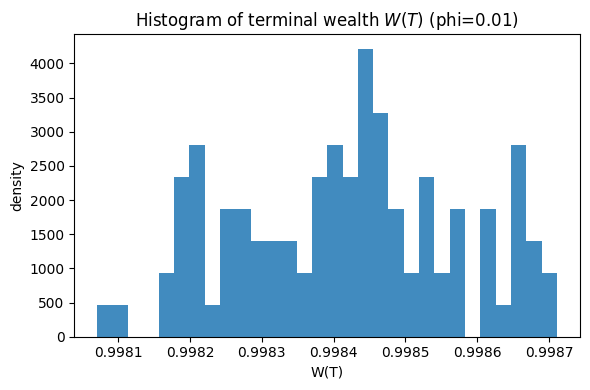

In [10]:
# ============================================================
# MODIFIED VERSION (extended path)
# Output/report ONLY:
#   - Inventory (10 realizations) + optional mean
#   - Trading speed (10 realizations) + optional mean
#   - Histogram of terminal wealth W(T)
#
# Assumes these already exist from your notebook:
#   brownian_midprice, fbm_davies_harte, price_process, stream_signature,
#   SpeedNet, model (the extension network), and constants:
#   dtype, device, M_train, N, T, dt_grid, q0, lam, alpha, H, t, S0, V0
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch

phis = [0.0, 0.001, 0.005, 0.01]

# your params (as in the snippet)
M_test = 100
a = 0.02
b = 0.02

@torch.no_grad()
def analytic_inventory(phi, q0, k_ana, alpha_ana, b_ana, t, T, eps=1e-14):
    # plotting only; you can delete if you do not want analytic overlay
    phi_t = torch.as_tensor(phi, device=t.device, dtype=t.dtype)
    if torch.abs(phi_t) < eps:
        return q0 * (1.0 - t / T)
    gamma = torch.sqrt(phi_t / k_ana)
    zeta = (alpha_ana - 0.5 * b_ana + torch.sqrt(k_ana * phi_t)) / (alpha_ana - 0.5 * b_ana - torch.sqrt(k_ana * phi_t))
    tt = T - t
    num = zeta * torch.exp(gamma * tt) - torch.exp(-gamma * tt)
    den = zeta * torch.exp(gamma * T)  - torch.exp(-gamma * T)
    return q0 * num / den

@torch.no_grad()
def speed_from_Q(Q, dt_grid):
    u = torch.zeros_like(Q)
    u[:-1] = (Q[:-1] - Q[1:]) / dt_grid
    u[-1] = u[-2]
    return u


def train_on_expected_sig_and_test(phi, epochs=1000, lr=1e-3, seed_train=0, seed_test=123):
    # -------------------------
    # TRAIN
    # -------------------------
    X_mid_train = brownian_midprice(M_train, seed=seed_train)
    fBm_train = fbm_davies_harte(M_train, N, T, H, seed=seed_train, device="cpu", dtype=torch.float64)
    t_rep_train = t.view(1, N, 1).repeat(M_train, 1, 1)

    X_path_train = torch.cat([t_rep_train, X_mid_train, fBm_train], dim=2)
    extension_train = model(X_path_train)                  # (M_train, N, ext_dim)
    stacked_train = torch.cat([X_path_train, extension_train], dim=2)

    sig_train = stream_signature(stacked_train)
    expected_sig = sig_train.mean(dim=0).unsqueeze(0).detach()  # (1, N, C)

    S_train, V_train = price_process(a, b, X_mid_train, fBm_train, S0, V0)
    Xbar_t = S_train.squeeze(-1).mean(dim=0)  # (N,)

    model1 = SpeedNet(expected_sig.shape[-1]).to(device).to(dtype)
    opt = torch.optim.Adam(model1.parameters(), lr=lr)

    loss_hist = []
    for _ in tqdm(range(epochs), leave=False):
        opt.zero_grad()

        theta = model1(expected_sig, dt_grid, q0).squeeze(0)  # (N,)

        I = torch.zeros_like(theta)
        I[1:] = torch.cumsum(theta[:-1] * dt_grid, dim=0)

        # keep your training price choice
        price = Xbar_t - lam * theta

        wealth = torch.zeros_like(theta)
        wealth[1:] = torch.cumsum((price[:-1] * theta[:-1]) * dt_grid, dim=0)

        inventory = q0 - I

        penalty = torch.zeros_like(theta)
        penalty[1:] = torch.cumsum((inventory[:-1] ** 2) * dt_grid, dim=0)

        obj_T = wealth[-1] - phi * penalty[-1] + inventory[-1] * (price[-1] - alpha * inventory[-1])
        loss = -obj_T
        loss_hist.append(float(loss.detach().cpu()))

        loss.backward()
        opt.step()

    # -------------------------
    # TEST
    # -------------------------
    X_mid_test = brownian_midprice(M_test, seed=seed_test)
    fBm_test = fbm_davies_harte(M_test, N, T, H, seed=seed_test, device="cpu", dtype=torch.float64)
    t_rep_test = t.view(1, N, 1).repeat(M_test, 1, 1)

    X_path_test = torch.cat([t_rep_test, X_mid_test, fBm_test], dim=2)
    with torch.no_grad():
        extension_test = model(X_path_test)
    stacked_test = torch.cat([X_path_test, extension_test], dim=2)

    sig_test = stream_signature(stacked_test)

    S_test, V_test = price_process(a, b, X_mid_test, fBm_test, S0, V0)
    X_t_test = S_test.squeeze(-1).mean(dim=0)  # (N,)

    model1.eval()
    with torch.no_grad():
        theta_test = model1(sig_test, dt_grid, q0)  # (M_test, N)

        I = torch.zeros_like(theta_test)
        I[:, 1:] = torch.cumsum(theta_test[:, :-1] * dt_grid.view(1, -1), dim=1)

        inventory = q0 - I  # (M_test, N)

        # keep your test price choice
        price = X_t_test - lam * theta_test

        wealth = torch.zeros_like(theta_test)
        wealth[:, 1:] = torch.cumsum((price[:, :-1] * theta_test[:, :-1]) * dt_grid.view(1, -1), dim=1)

    # 10 realizations
    inv_10 = inventory[:10].detach().cpu().numpy()      # (10, N)
    th_10  = theta_test[:10].detach().cpu().numpy()     # (10, N)

    # terminal wealth distribution
    wealth_T = wealth[:, -1].detach().cpu().numpy()     # (M_test,)

    # optional means (sometimes useful)
    inv_mean = inventory.mean(dim=0).detach().cpu().numpy()
    th_mean  = theta_test.mean(dim=0).detach().cpu().numpy()

    return inv_10, th_10, inv_mean, th_mean, wealth_T, np.array(loss_hist)


# ============================================================
# RUN + PLOT: inventory/speed (10 realizations + analytic) and wealth histogram
# ============================================================
t_cpu = t.detach().cpu().numpy()

# analytic params (overlay only)
b_ana = 0.001
k_ana = 1e-3
alpha_ana = 100.0

results = {}
for phi in phis:
    inv_10, th_10, inv_mean, th_mean, wealth_T, loss_hist = train_on_expected_sig_and_test(
        phi, epochs=1000, lr=1e-3
    )
    results[phi] = dict(
        inv_10=inv_10, th_10=th_10,
        inv_mean=inv_mean, th_mean=th_mean,
        wealth_T=wealth_T, loss=loss_hist
    )

# ---- Inventory + speed plots (one figure per phi)
for phi in phis:
    r = results[phi]

    # analytic overlay (plotting only)
    Q_an_t = analytic_inventory(phi, q0, k_ana, alpha_ana, b_ana, t, T)
    u_an_t = speed_from_Q(Q_an_t, dt_grid)

    Q_an = Q_an_t.detach().cpu().numpy()
    u_an = u_an_t.detach().cpu().numpy()

    fig, axs = plt.subplots(1, 2, figsize=(13, 4))

    # Inventory
    axs[0].plot(t_cpu, Q_an, "k--", linewidth=2.5, label="analytic $Q(t)$")
    for i in range(10):
        axs[0].plot(t_cpu, r["inv_10"][i], alpha=0.7)
    axs[0].plot(t_cpu, r["inv_mean"], "k", linewidth=2.0, label="mean learned")
    axs[0].set_title(f"Inventory: analytic + 10 realizations (phi={phi})")
    axs[0].set_xlabel("t")
    axs[0].set_ylabel("Q(t)")
    axs[0].legend(fontsize=8)

    # Trading speed
    axs[1].plot(t_cpu, u_an, "k--", linewidth=2.5, label="analytic $u(t)$")
    for i in range(10):
        axs[1].plot(t_cpu, r["th_10"][i], alpha=0.7)
    axs[1].plot(t_cpu, r["th_mean"], "k", linewidth=2.0, label="mean learned")
    axs[1].set_title(f"Trading speed: analytic + 10 realizations (phi={phi})")
    axs[1].set_xlabel("t")
    axs[1].set_ylabel("u(t)")
    axs[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

# ---- Wealth histogram (one figure per phi)
for phi in phis:
    w = results[phi]["wealth_T"]
    plt.figure(figsize=(6, 4))
    plt.hist(w, bins=30, density=True, alpha=0.85)
    plt.title(f"Histogram of terminal wealth $W(T)$ (phi={phi})")
    plt.xlabel("W(T)")
    plt.ylabel("density")
    plt.tight_layout()
    plt.show()

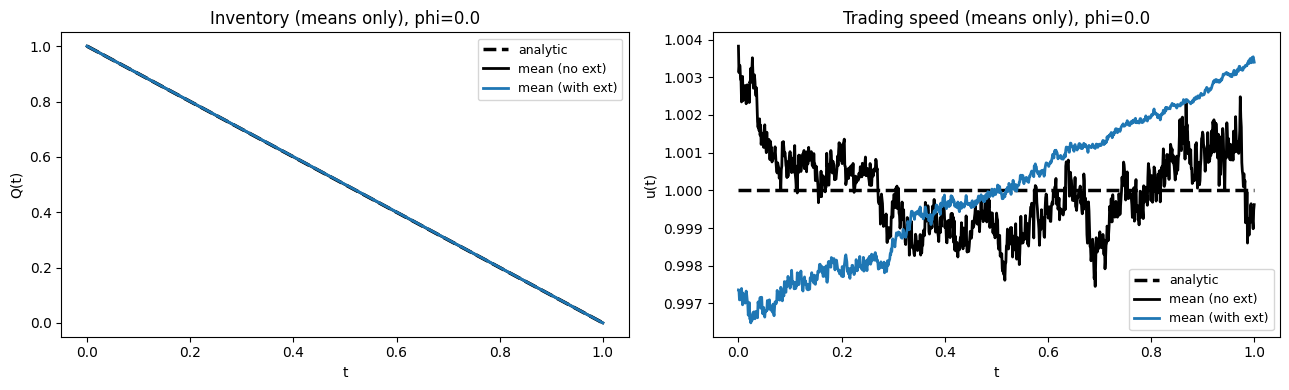

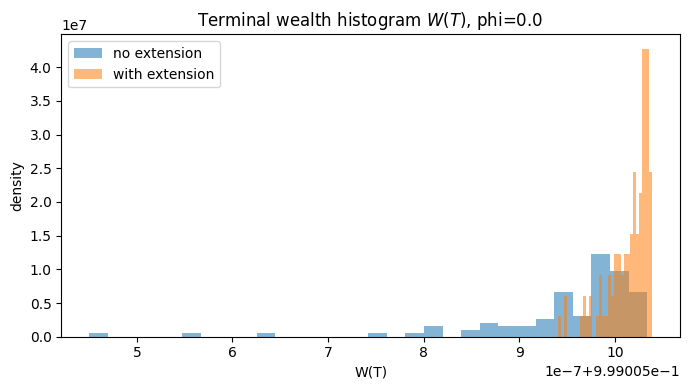

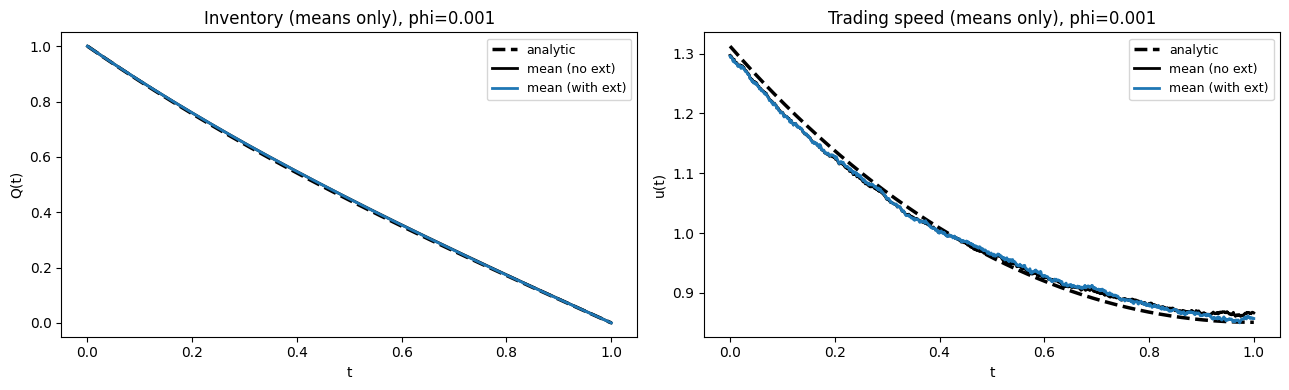

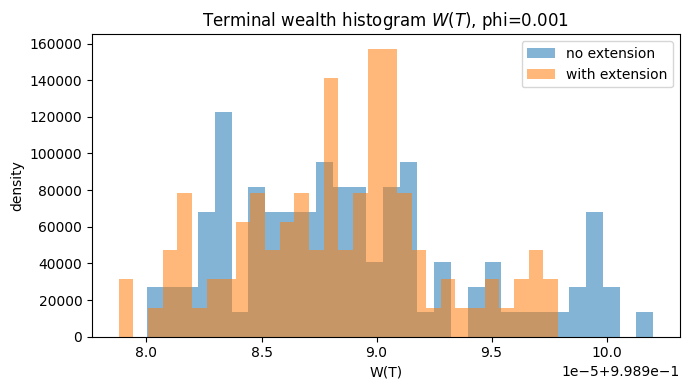

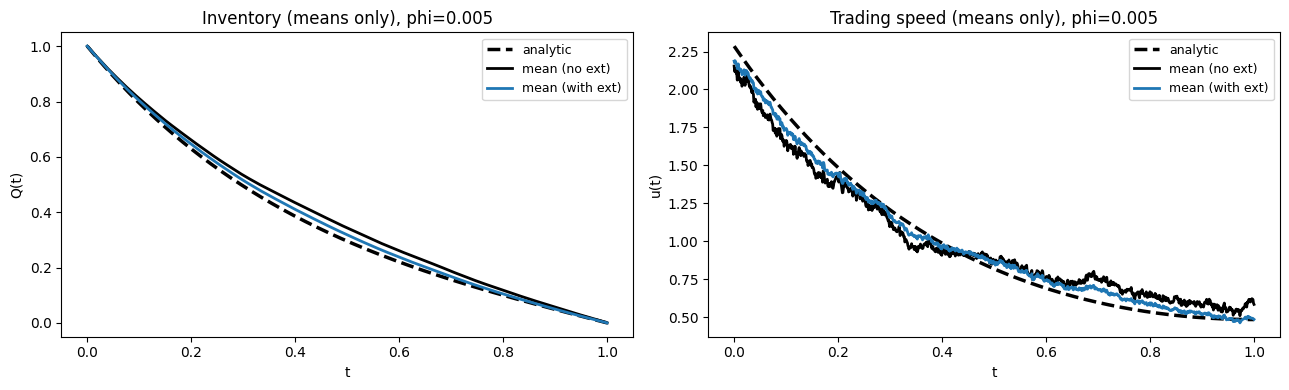

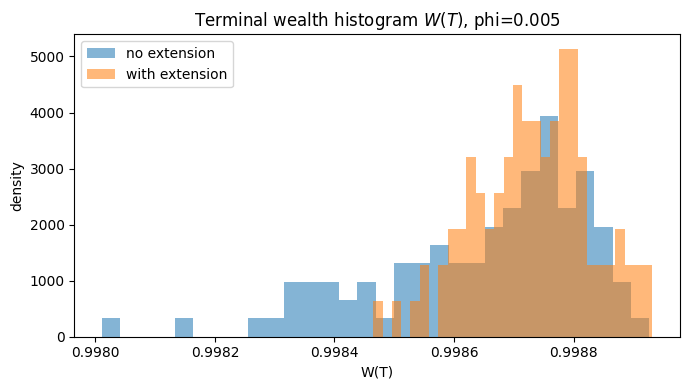

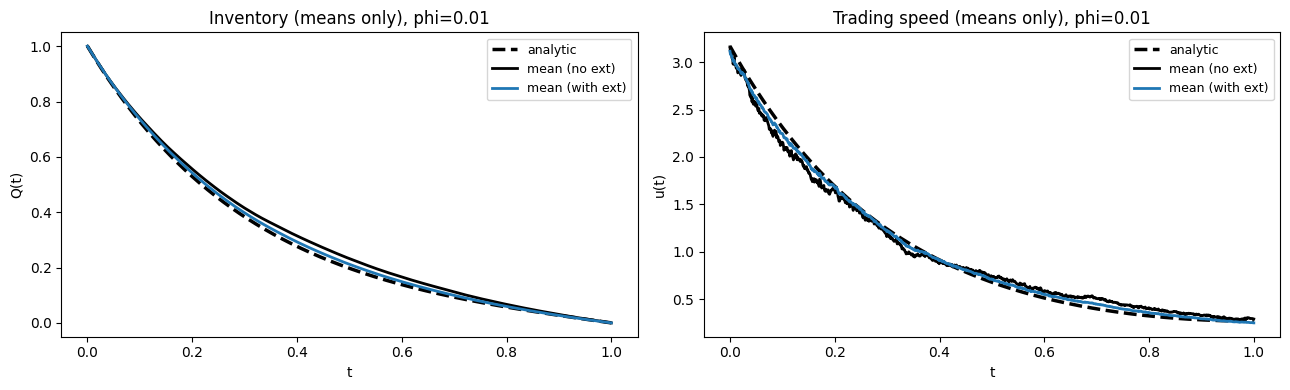

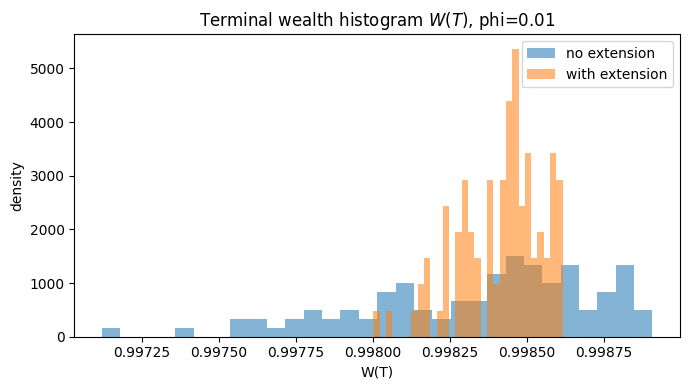

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm

# ----------------------------
# Analytic (plotting only)
# ----------------------------
b_ana = 0.001
k_ana = 1e-3
alpha_ana = 100.0

def analytic_inventory(phi, q0, k, alpha, b, t, T, eps=1e-14):
    phi_t = torch.as_tensor(phi, device=t.device, dtype=t.dtype)
    if torch.abs(phi_t) < eps:
        return q0 * (1.0 - t / T)
    gamma = torch.sqrt(phi_t / k)
    zeta = (alpha - 0.5 * b + torch.sqrt(k * phi_t)) / (alpha - 0.5 * b - torch.sqrt(k * phi_t))
    tt = T - t
    num = zeta * torch.exp(gamma * tt) - torch.exp(-gamma * tt)
    den = zeta * torch.exp(gamma * T)  - torch.exp(-gamma * T)
    return q0 * num / den

def speed_from_Q(Q, dt_grid):
    u = torch.zeros_like(Q)
    u[:-1] = (Q[:-1] - Q[1:]) / dt_grid
    u[-1] = u[-2]
    return u

# ----------------------------
# Core helper: compute inventory from speed
# ----------------------------
def inventory_from_speed(theta, q0, dt_grid):
    # theta: (M,N) or (N,)
    if theta.dim() == 1:
        I = torch.zeros_like(theta)
        I[1:] = torch.cumsum(theta[:-1] * dt_grid, dim=0)
        return q0 - I
    I = torch.zeros_like(theta)
    I[:, 1:] = torch.cumsum(theta[:, :-1] * dt_grid.view(1, -1), dim=1)
    return q0 - I


# ============================================================
# 1) WITHOUT extension: signature of [t, BM, fBM]
# ============================================================
def train_no_extension(phi, epochs=1000, lr=1e-3, seed_train=0, seed_test=123):
    # TRAIN
    X_mid_train = brownian_midprice(M_train, seed=seed_train)
    fBm_train = fbm_davies_harte(M_train, N, T, H, seed=seed_train, device="cpu", dtype=torch.float64)
    t_rep_train = t.view(1, N, 1).repeat(M_train, 1, 1)

    X_path_train = torch.cat([t_rep_train, X_mid_train, fBm_train], dim=2)  # (M,N,3)
    sig_train = stream_signature(X_path_train)
    expected_sig = sig_train.mean(dim=0).unsqueeze(0).detach()              # (1,N,C)

    S_train, V_train = price_process(a, b, X_mid_train, fBm_train, S0, V0)
    Xbar_t = S_train.squeeze(-1).mean(dim=0)                                # (N,)

    model_speed = SpeedNet(expected_sig.shape[-1]).to(device).to(dtype)
    opt = torch.optim.Adam(model_speed.parameters(), lr=lr)

    for _ in tqdm(range(epochs), leave=False):
        opt.zero_grad()
        theta = model_speed(expected_sig, dt_grid, q0).squeeze(0)            # (N,)

        Q = inventory_from_speed(theta, q0, dt_grid)                         # (N,)
        I = q0 - Q
        price = Xbar_t - lam * theta                                         # keep your choice
        wealth = torch.zeros_like(theta)
        wealth[1:] = torch.cumsum((price[:-1] * theta[:-1]) * dt_grid, dim=0)

        penalty = torch.zeros_like(theta)
        penalty[1:] = torch.cumsum((Q[:-1] ** 2) * dt_grid, dim=0)

        obj_T = wealth[-1] - phi * penalty[-1] + Q[-1] * (price[-1] - alpha * Q[-1])
        loss = -obj_T
        loss.backward()
        opt.step()

    # TEST
    X_mid_test = brownian_midprice(M_test, seed=seed_test)
    fBm_test = fbm_davies_harte(M_test, N, T, H, seed=seed_test, device="cpu", dtype=torch.float64)
    t_rep_test = t.view(1, N, 1).repeat(M_test, 1, 1)

    X_path_test = torch.cat([t_rep_test, X_mid_test, fBm_test], dim=2)
    sig_test = stream_signature(X_path_test)

    S_test, V_test = price_process(a, b, X_mid_test, fBm_test, S0, V0)
    X_t_test = S_test.squeeze(-1).mean(dim=0)                                # (N,)

    model_speed.eval()
    with torch.no_grad():
        theta_test = model_speed(sig_test, dt_grid, q0)                      # (M,N)
        Q_test = inventory_from_speed(theta_test, q0, dt_grid)               # (M,N)
        price_test = X_t_test - lam * theta_test
        wealth_test = torch.zeros_like(theta_test)
        wealth_test[:, 1:] = torch.cumsum((price_test[:, :-1] * theta_test[:, :-1]) * dt_grid.view(1, -1), dim=1)



    inv_m  = Q_test.mean(dim=0).detach().cpu().numpy()
    th_m   = theta_test.mean(dim=0).detach().cpu().numpy()
    wealth_T = wealth_test[:, -1].detach().cpu().numpy()


    return dict(inv_m=inv_m, th_m=th_m, wealth_T=wealth_T)


# ============================================================
# 2) WITH extension: signature of [t, BM, fBM, extension]
# ============================================================
def train_with_extension(phi, epochs=1000, lr=1e-3, seed_train=0, seed_test=123):
    # TRAIN
    X_mid_train = brownian_midprice(M_train, seed=seed_train)
    fBm_train = fbm_davies_harte(M_train, N, T, H, seed=seed_train, device="cpu", dtype=torch.float64)
    t_rep_train = t.view(1, N, 1).repeat(M_train, 1, 1)

    X_path_train = torch.cat([t_rep_train, X_mid_train, fBm_train], dim=2)

    model.eval()
    with torch.no_grad():
        ext_train = model(X_path_train)
    stacked_train = torch.cat([X_path_train, ext_train], dim=2)

    sig_train = stream_signature(stacked_train)
    expected_sig = sig_train.mean(dim=0).unsqueeze(0).detach()

    S_train, V_train = price_process(a, b, X_mid_train, fBm_train, S0, V0)
    Xbar_t = S_train.squeeze(-1).mean(dim=0)

    model_speed = SpeedNet(expected_sig.shape[-1]).to(device).to(dtype)
    opt = torch.optim.Adam(model_speed.parameters(), lr=lr)

    for _ in tqdm(range(epochs), leave=False):
        opt.zero_grad()
        theta = model_speed(expected_sig, dt_grid, q0).squeeze(0)

        Q = inventory_from_speed(theta, q0, dt_grid)
        I = q0 - Q
        price = Xbar_t - lam * theta
        wealth = torch.zeros_like(theta)
        wealth[1:] = torch.cumsum((price[:-1] * theta[:-1]) * dt_grid, dim=0)

        penalty = torch.zeros_like(theta)
        penalty[1:] = torch.cumsum((Q[:-1] ** 2) * dt_grid, dim=0)

        obj_T = wealth[-1] - phi * penalty[-1] + Q[-1] * (price[-1] - alpha * Q[-1])
        loss = -obj_T
        loss.backward()
        opt.step()

    # TEST
    X_mid_test = brownian_midprice(M_test, seed=seed_test)
    fBm_test = fbm_davies_harte(M_test, N, T, H, seed=seed_test, device="cpu", dtype=torch.float64)
    t_rep_test = t.view(1, N, 1).repeat(M_test, 1, 1)

    X_path_test = torch.cat([t_rep_test, X_mid_test, fBm_test], dim=2)
    with torch.no_grad():
        ext_test = model(X_path_test)
    stacked_test = torch.cat([X_path_test, ext_test], dim=2)

    sig_test = stream_signature(stacked_test)

    S_test, V_test = price_process(a, b, X_mid_test, fBm_test, S0, V0)
    X_t_test = S_test.squeeze(-1).mean(dim=0)

    model_speed.eval()
    with torch.no_grad():
        theta_test = model_speed(sig_test, dt_grid, q0)
        Q_test = inventory_from_speed(theta_test, q0, dt_grid)
        price_test = X_t_test - lam * theta_test
        wealth_test = torch.zeros_like(theta_test)
        wealth_test[:, 1:] = torch.cumsum((price_test[:, :-1] * theta_test[:, :-1]) * dt_grid.view(1, -1), dim=1)

    inv_m  = Q_test.mean(dim=0).detach().cpu().numpy()
    th_m   = theta_test.mean(dim=0).detach().cpu().numpy()
    wealth_T = wealth_test[:, -1].detach().cpu().numpy()

    return dict(inv_m=inv_m, th_m=th_m, wealth_T=wealth_T)



# ============================================================
# Run comparison and plot
# ============================================================
phis = [0.0, 0.001, 0.005, 0.01]
t_cpu = t.detach().cpu().numpy()

res_noext = {}
res_ext = {}

for phi in phis:
    res_noext[phi] = train_no_extension(phi, epochs=1000, lr=1e-3)
    res_ext[phi]   = train_with_extension(phi, epochs=1000, lr=1e-3)

for phi in phis:
    Q_an = analytic_inventory(phi, q0, k_ana, alpha_ana, b_ana, t, T).detach().cpu().numpy()
    u_an = speed_from_Q(torch.tensor(Q_an, dtype=t.dtype), dt_grid).detach().cpu().numpy()

    fig, axs = plt.subplots(1, 2, figsize=(13, 4))

    # Inventory: analytic + mean(no ext) + mean(with ext)
    axs[0].plot(t_cpu, Q_an, "k--", lw=2.5, label="analytic")
    axs[0].plot(t_cpu, res_noext[phi]["inv_m"], "k", lw=2.0, label="mean (no ext)")
    axs[0].plot(t_cpu, res_ext[phi]["inv_m"], lw=2.0, label="mean (with ext)")
    axs[0].set_title(f"Inventory (means only), phi={phi}")
    axs[0].set_xlabel("t")
    axs[0].set_ylabel("Q(t)")
    axs[0].legend(fontsize=9)

    # Speed: analytic + mean(no ext) + mean(with ext)
    axs[1].plot(t_cpu, u_an, "k--", lw=2.5, label="analytic")
    axs[1].plot(t_cpu, res_noext[phi]["th_m"], "k", lw=2.0, label="mean (no ext)")
    axs[1].plot(t_cpu, res_ext[phi]["th_m"], lw=2.0, label="mean (with ext)")
    axs[1].set_title(f"Trading speed (means only), phi={phi}")
    axs[1].set_xlabel("t")
    axs[1].set_ylabel("u(t)")
    axs[1].legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    # Wealth histogram: no ext vs ext
    plt.figure(figsize=(7, 4))
    plt.hist(res_noext[phi]["wealth_T"], bins=30, density=True, alpha=0.55, label="no extension")
    plt.hist(res_ext[phi]["wealth_T"],   bins=30, density=True, alpha=0.55, label="with extension")
    plt.title(f"Terminal wealth histogram $W(T)$, phi={phi}")
    plt.xlabel("W(T)")
    plt.ylabel("density")
    plt.legend()
    plt.tight_layout()
    plt.show()